In [ ]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html  #installs the torch-scatter library for efficient graph operations
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html  #installs the torch-sparse library, which provides efficient sparse matrix operations for PyTorch Geometric
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git   #installs the latest development version of PyTorch Geometric (PyG) GitHub repository

# Helper function for visualization.
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt


def visualize_graph(G, color):           #Defines a function to visualize a graph with specified node colors.
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2")
    plt.show()


def visualize_embedding(h, color, epoch=None, loss=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    h = h.detach().cpu().numpy()
    plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
    if epoch is not None and loss is not None:
        plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=16)
    plt.show()

2.10.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Introduction: Hands-on Graph Neural Networks

Recently, deep learning on graphs has emerged to one of the hottest research fields in the deep learning community.
Here, **Graph Neural Networks (GNNs)** aim to generalize classical deep learning concepts to irregular structured data (in contrast to images or texts) and to enable neural networks to reason about objects and their relations.

This is done by following a simple **neural message passing scheme**, where node features $\mathbf{x}_v^{(\ell)}$ of all nodes $v \in \mathcal{V}$ in a graph $\mathcal{G} = (\mathcal{V}, \mathcal{E})$ are iteratively updated by aggregating localized information from their neighbors $\mathcal{N}(v)$:

$$
\mathbf{x}_v^{(\ell + 1)} = f^{(\ell + 1)}_{\theta} \left( \mathbf{x}_v^{(\ell)}, \left\{ \mathbf{x}_w^{(\ell)} : w \in \mathcal{N}(v) \right\} \right)
$$

This tutorial will introduce you to some fundamental concepts regarding deep learning on graphs via Graph Neural Networks based on the **[PyTorch Geometric (PyG) library](https://github.com/rusty1s/pytorch_geometric)**.
PyTorch Geometric is an extension library to the popular deep learning framework [PyTorch](https://pytorch.org/), and consists of various methods and utilities to ease the implementation of Graph Neural Networks.

Following [Kipf et al. (2017)](https://arxiv.org/abs/1609.02907), let's dive into the world of GNNs by looking at a simple graph-structured example, the well-known [**Zachary's karate club network**](https://en.wikipedia.org/wiki/Zachary%27s_karate_club). This graph describes a social network of 34 members of a karate club and documents links between members who interacted outside the club. Here, we are interested in detecting communities that arise from the member's interaction.

PyTorch Geometric provides an easy access to this dataset via the [`torch_geometric.datasets`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets) subpackage:

In [ ]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


After initializing the [`KarateClub`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.KarateClub) dataset, we first can inspect some of its properties.
For example, we can see that this dataset holds exactly **one graph**, and that each node in this dataset is assigned a **34-dimensional feature vector** (which uniquely describes the members of the karate club).
Furthermore, the graph holds exactly **4 classes**, which represent the community each node belongs to.

Let's now look at the underlying graph in more detail:

Why each node has 34 features

In the KarateClub dataset documentation, each node has 34 features because PyTorch Geometric uses an identity matrix (one-hot encoding) as node features.

There are: 34 nodes total
so each node gets a unique 34-dimensional feature vector.

In [ ]:
data = dataset[0]  # Get the first graph object.
print(data)
print('==============================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Has isolated nodes: False
Has self-loops: False
Is undirected: True


Each graph in PyTorch Geometric is represented by a single [`Data`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data) object, which holds all the information to describe its graph representation.
We can print the data object anytime via `print(data)` to receive a short summary about its attributes and their shapes:
```
Data(edge_index=[2, 156], x=[34, 34], y=[34], train_mask=[34])
```
We can see that this `data` object holds 4 attributes:
(1) The `edge_index` property holds the information about the **graph connectivity**, *i.e.*, a tuple of source and destination node indices for each edge.
PyG further refers to (2) **node features** as `x` (each of the 34 nodes is assigned a 34-dim feature vector), and to (3) **node labels** as `y` (each node is assigned to exactly one class).
(4) There also exists an additional attribute called `train_mask`, which describes for which nodes we already know their community assigments.
In total, we are only aware of the ground-truth labels of 4 nodes (one for each community), and the task is to infer the community assignment for the remaining nodes.

The `data` object also provides some **utility functions** to infer some basic properties of the underlying graph.
For example, we can easily infer whether there exists isolated nodes in the graph (*i.e.* there exists no edge to any node), whether the graph contains self-loops (*i.e.*, $(v, v) \in \mathcal{E}$), or whether the graph is undirected (*i.e.*, for each edge $(v, w) \in \mathcal{E}$ there also exists the edge $(w, v) \in \mathcal{E}$).

Let us now inspect the `edge_index` property in more detail:

In Pytorch, Edges are stored in COO format, COO (Coordinate Format) is a way to store sparse graph connections efficiently.
Structure of COO Format

It uses a matrix of shape: [2,E]

where:

first row → source nodes
second row → destination nodes
E = number of edges

edge_index = [
    [0, 1, 2],
    [1, 2, 0]
]

Edges are
0 → 1

1 → 2

2 → 0

Why Use COO Format?

Graphs are usually sparse:

many possible connections
few actual edges

Instead of storing a huge adjacency matrix full of zeros, COO stores only existing edges.

Efficient for:

memory
graph computations
GNN message passing



y=[34]

Node labels/classes
Shape:

[34]

Meaning:

one label per node
34 node labels total

In [ ]:
#from IPython.display import Javascript  # Restrict height of output cell.
#display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

edge_index = data.edge_index
print(edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

By printing `edge_index`, we can understand how PyG represents graph connectivity internally.
We can see that for each edge, `edge_index` holds a tuple of two node indices, where the first value describes the node index of the source node and the second value describes the node index of the destination node of an edge.

This representation is known as the **COO format (coordinate format)** commonly used for representing sparse matrices.
Instead of holding the adjacency information in a dense representation $\mathbf{A} \in \{ 0, 1 \}^{|\mathcal{V}| \times |\mathcal{V}|}$, PyG represents graphs sparsely, which refers to only holding the coordinates/values for which entries in $\mathbf{A}$ are non-zero.

Importantly, PyG does not distinguish between directed and undirected graphs, and treats undirected graphs as a special case of directed graphs in which reverse edges exist for every entry in `edge_index`.

We can further visualize the graph by converting it to the `networkx` library format, which implements, in addition to graph manipulation functionalities, powerful tools for visualization:

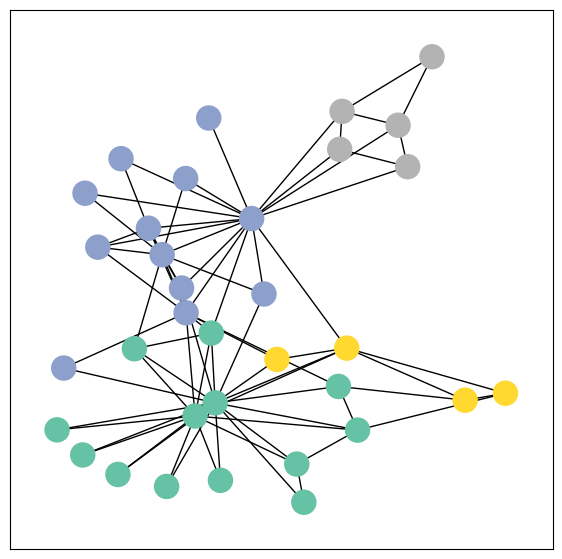

In [ ]:
from torch_geometric.utils import to_networkx # Imports the to_networkx function from PyTorch Geometric utilities
                                              #documentation to convert PyG graphs into NetworkX graphs.#

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)   #Visualizes the graph G and colors nodes using data.y (node labels/classes).


## Implementing Graph Neural Networks



PyG implements this layer via [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv), which can be executed by passing in the node feature representation `x` and the COO graph connectivity representation `edge_index`.

With this, we are ready to create our first Graph Neural Network by defining our network architecture in a `torch.nn.Module` class:

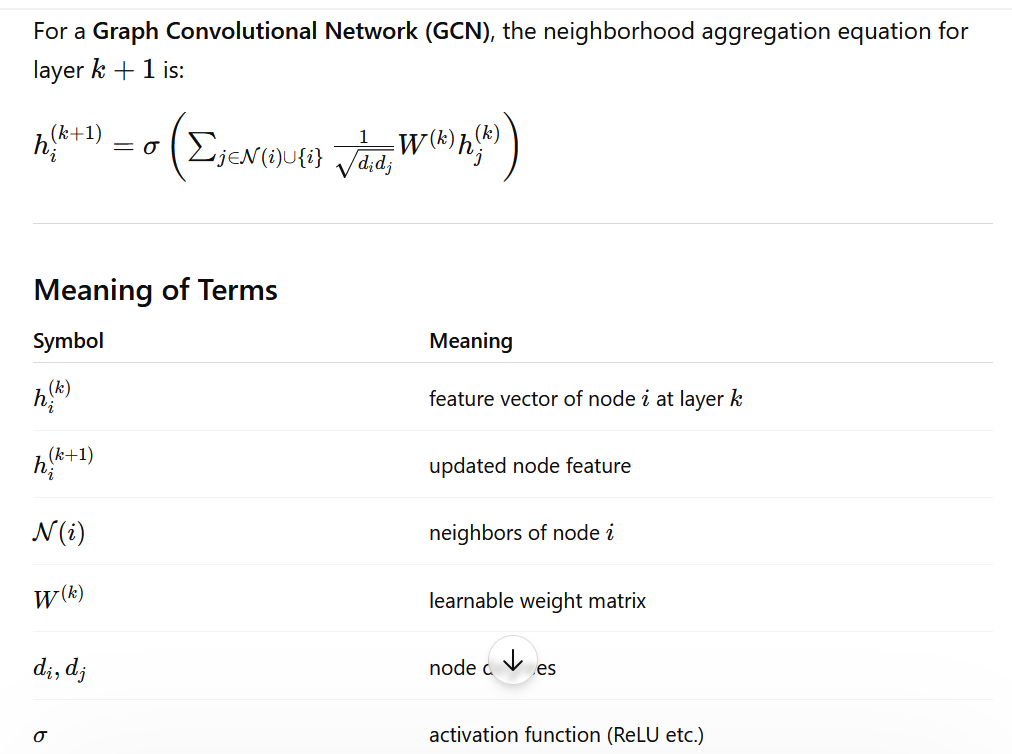

What Happens

For node i:

1. collect neighbor features
2. normalize by node degrees
3. multiply by learnable weights
4. apply activation function

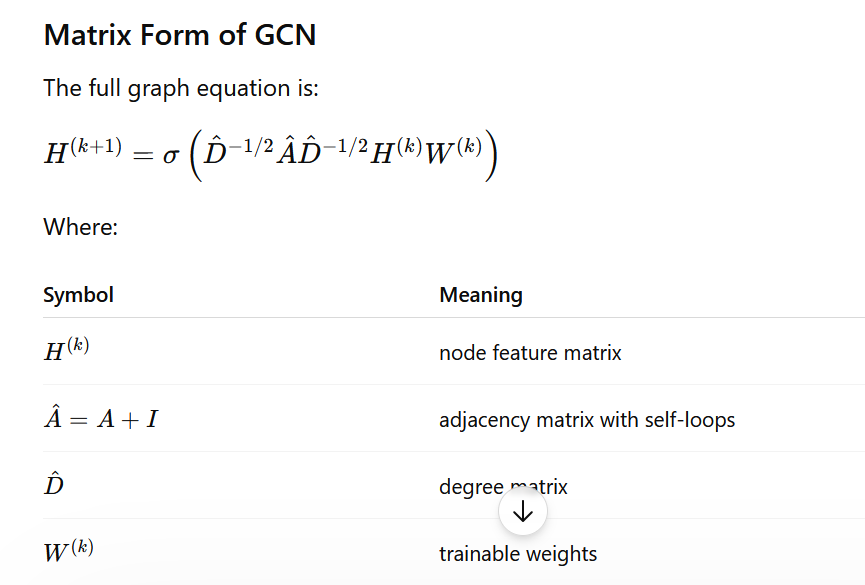

In [ ]:
import torch                          #Imports the main PyTorch library, Used for building and training neural networks
from torch.nn import Linear           #Imports a Linear layer (fully connected layer). It performs a mathematical transformation: y=Wx+b. Usually used for final classification.
from torch_geometric.nn import GCNConv # Imports the GCNConv layer from PyTorch Geometric. GCNConv is the main layer used in a Graph Convolutional Network (GCN).
                                       #It allows nodes to learn from their neighboring nodes.


class GCN(torch.nn.Module):           # Defines a new neural network class named GCN.Inherits from torch.nn.Module, which is the base class for all neural networks in PyTorch.
    def __init__(self):               # The constructor function initializes the model layers.Runs automatically when you create the model.
        super().__init__()            #Calls the parent (Module) constructor. Required to properly initialize the neural network.
        torch.manual_seed(1234)       #Sets a random seed for reproducibility. Ensures you get the same random initialization every time.
        self.conv1 = GCNConv(dataset.num_features, 4) #First graph convolution layer. Input = number of node features.Output: 4 hidden features per node.
        self.conv2 = GCNConv(4, 4)    #Second GCN layer.Takes 4 features from previous layer. Outputs 4 new features.
        self.conv3 = GCNConv(4, 2)    # Third GCN layer. Reduces node representation from 4 features to 2 features. These 2 values become the final node embeddings.
        self.classifier = Linear(2, dataset.num_classes) #A fully connected layer for classification. Input: 2-dimensional node embeddings.
                                                          #Output: dataset.num_classes predictions.


    def forward(self, x, edge_index):   # Defines how data flows through the network. Inputs:x→ node feature matrix. edge_index→ graph connections (which nodes are connected).
        h = self.conv1(x, edge_index)   #First GCN Layer, Applies graph convolution. Each node gathers information from neighbors.
        h = h.tanh()                    # Applies Tanh activation function. Adds non-linearity so the model can learn complex patterns.
                                        #Tanh output range: −1 to 1
        h = self.conv2(h, edge_index)   #Second GCN Layer,Processes updated node features again using neighbor information.
        h = h.tanh()                    #Applies Tanh activation again.
        h = self.conv3(h, edge_index)    #Third GCN Layer,Produces final node embeddings. Final GNN embedding space.
        h = h.tanh()                     # Final activation function. h now contains the learned graph representations. h stores compressed learned features for each node.

        # Apply a final (linear) classifier.
        out = self.classifier(h)            #Classification Layer- Converts embeddings into class scores. Produces prediction logits.

        return out, h                       #Return Outputs, out→ class predictions. h→ learned node embeddings.

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


Here, we first initialize all of our building blocks in `__init__` and define the computation flow of our network in `forward`.
We first define and stack **three graph convolution layers**, which corresponds to aggregating 3-hop neighborhood information around each node (all nodes up to 3 "hops" away).
In addition, the `GCNConv` layers reduce the node feature dimensionality to $2$, *i.e.*, $34 \rightarrow 4 \rightarrow 4 \rightarrow 2$. Each `GCNConv` layer is enhanced by a [tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html?highlight=tanh#torch.nn.Tanh) non-linearity.

After that, we apply a single linear transformation ([`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear)) that acts as a classifier to map our nodes to 1 out of the 4 classes/communities.

We return both the output of the final classifier as well as the final node embeddings produced by our GNN.
We proceed to initialize our final model via `GCN()`, and printing our model produces a summary of all its used sub-modules.


### Embedding the Karate Club Network

Let's take a look at the node embeddings produced by our GNN.
Here, we pass in the initial node features `x` and the graph connectivity information `edge_index` to the model, and visualize its 2-dimensional embedding.

Step-by-Step Shape Flow

Suppose: Graph has N nodes
Each node initially has F features

Then: Input =x.shape = [N, F]

.............................................................

After conv1, h = self.conv1(x, edge_index)

Shape becomes:[N, 4] because:

GCNConv(dataset.num_features, 4)

outputs 4 features per node.

...............................................

After conv2
h = self.conv2(h, edge_index)

Shape remains: [N, 4]

........................................................

After conv3
h = self.conv3(h, edge_index)

Shape becomes: [N, 2]

.......................................

After tanh
h = h.tanh()

Activation functions do not change shape.

So shape is still: [N, 2]

Inputs:

data.x → Node feature matrix
Shape: [num_nodes, num_features]


For Karate Club, each row represents a node's features.
data.edge_index → Graph connectivity information
Stores which nodes are connected by edges.

What happens inside the GCN?

Each node gathers information from its neighbors.
Multiple GCN layers aggregate neighborhood information repeatedly.
The model produces embeddings for all nodes.


Embedding shape: [34, 2]


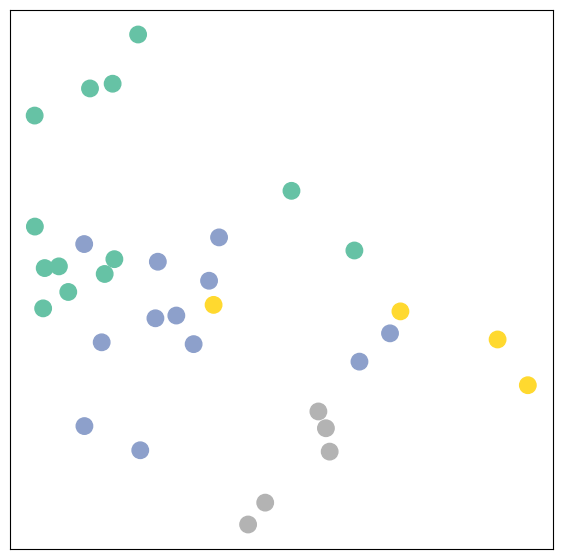

In [ ]:
model = GCN()               #Creates an instance of the GCN model.The model typically contains one or more graph convolution layers.

_, h = model(data.x, data.edge_index)              #The model returns: _ → Usually the final prediction. h → Hidden node embeddings learned by the GCN.
print(f'Embedding shape: {list(h.shape)}')          #Displays the dimensions of the learned embeddings.

visualize_embedding(h, color=data.y)

Remarkably, even before training the weights of our model, the model produces an embedding of nodes that closely resembles the community-structure of the graph.
Nodes of the same color (community) are already closely clustered together in the embedding space, although the weights of our model are initialized **completely at random** and we have not yet performed any training so far!
This leads to the conclusion that GNNs introduce a strong inductive bias, leading to similar embeddings for nodes that are close to each other in the input graph.

### Training on the Karate Club Network

But can we do better? Let's look at an example on how to train our network parameters based on the knowledge of the community assignments of 4 nodes in the graph (one for each community):

Since everything in our model is differentiable and parameterized, we can add some labels, train the model and observse how the embeddings react.
Here, we make use of a semi-supervised or transductive learning procedure: We simply train against one node per class, but are allowed to make use of the complete input graph data.

Training our model is very similar to any other PyTorch model.
In addition to defining our network architecture, we define a loss critertion (here, [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)) and initialize a stochastic gradient optimizer (here, [`Adam`](https://pytorch.org/docs/stable/optim.html?highlight=adam#torch.optim.Adam)).
After that, we perform multiple rounds of optimization, where each round consists of a forward and backward pass to compute the gradients of our model parameters w.r.t. to the loss derived from the forward pass.
If you are not new to PyTorch, this scheme should appear familar to you.
Otherwise, the PyTorch docs provide [a good introduction on how to train a neural network in PyTorch](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-loss-function-and-optimizer).

Note that our semi-supervised learning scenario is achieved by the following line:
```
loss = criterion(out[data.train_mask], data.y[data.train_mask])
```
While we compute node embeddings for all of our nodes, we **only make use of the training nodes for computing the loss**.
Here, this is implemented by filtering the output of the classifier `out` and ground-truth labels `data.y` to only contain the nodes in the `train_mask`.

Let us now start training and see how our node embeddings evolve over time (best experienced by explicitely running the code):

<IPython.core.display.Javascript object>

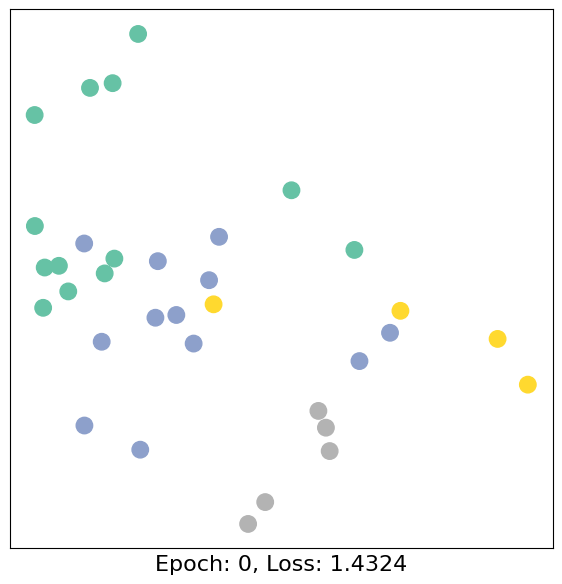

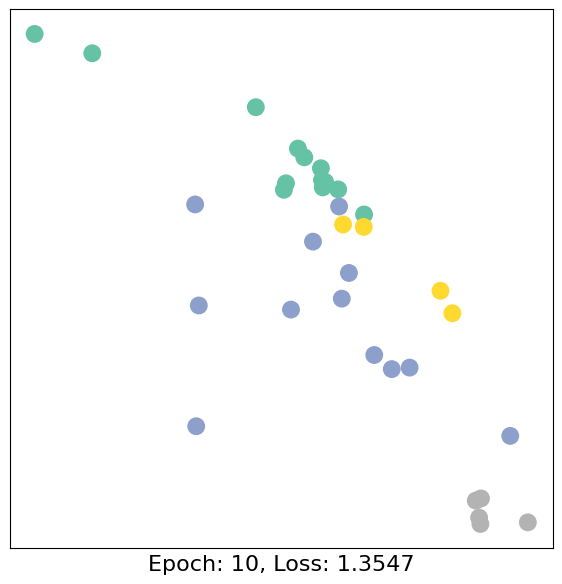

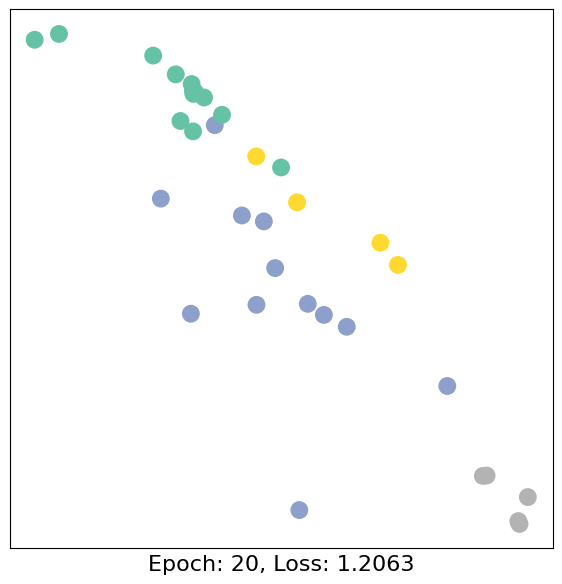

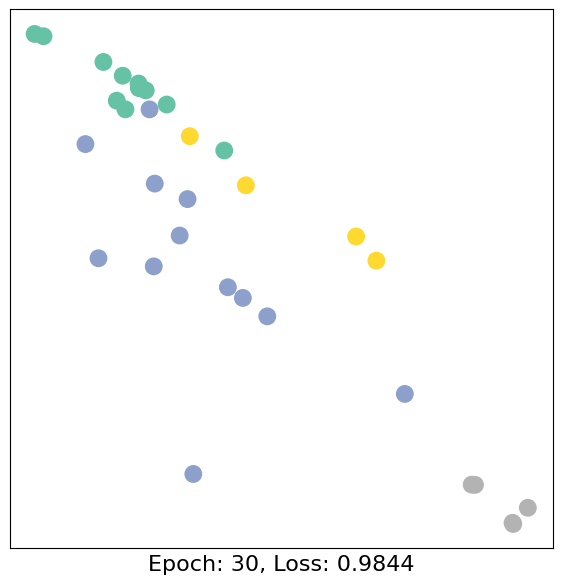

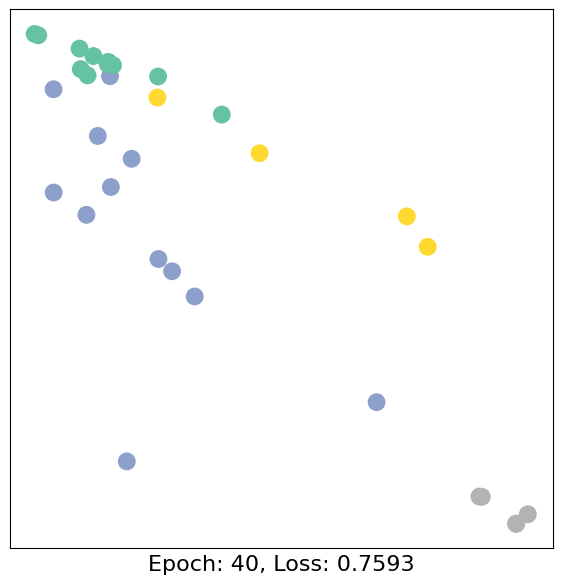

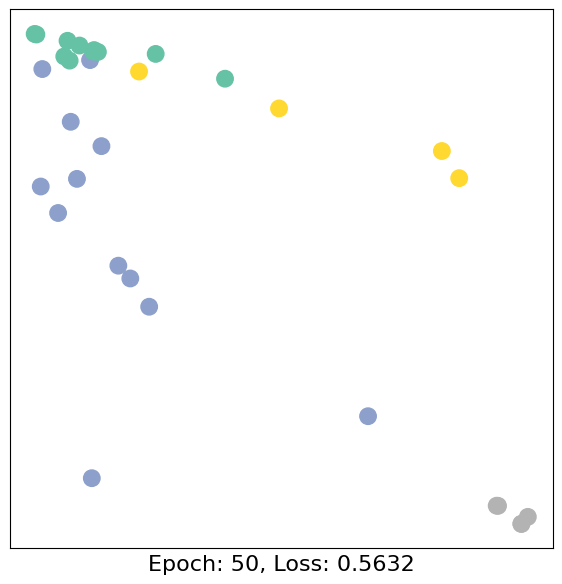

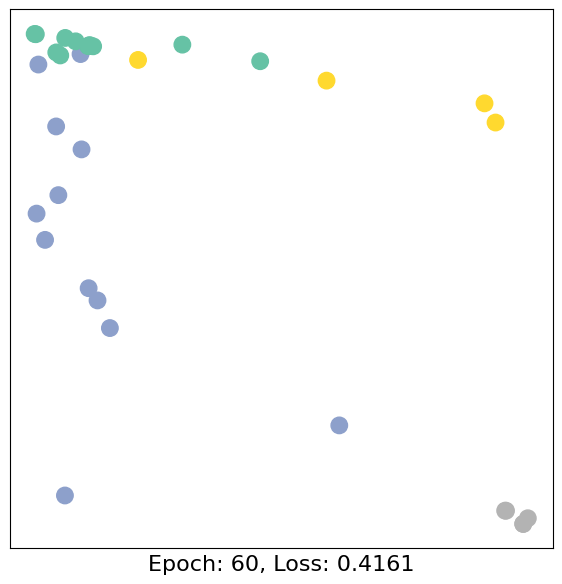

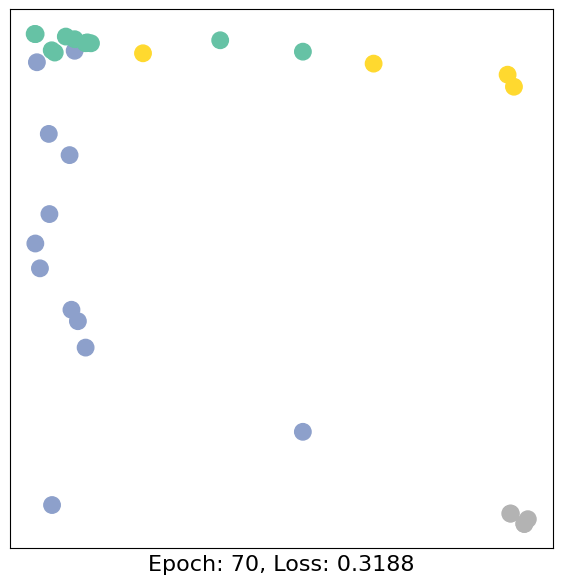

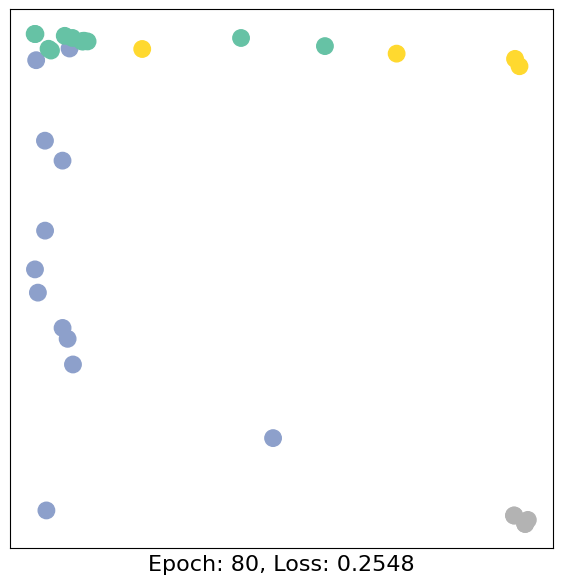

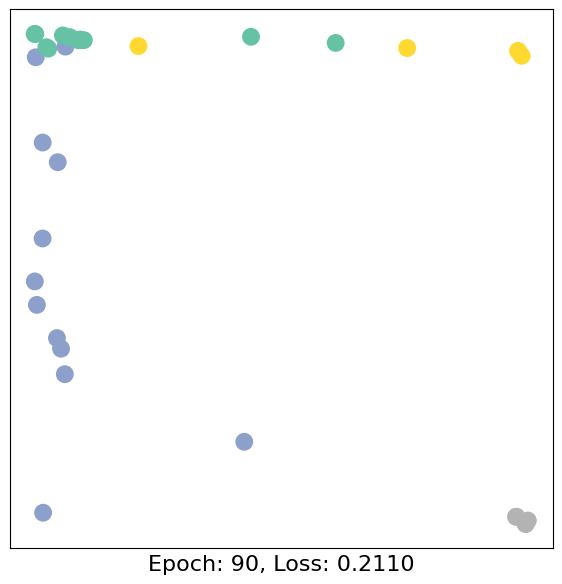

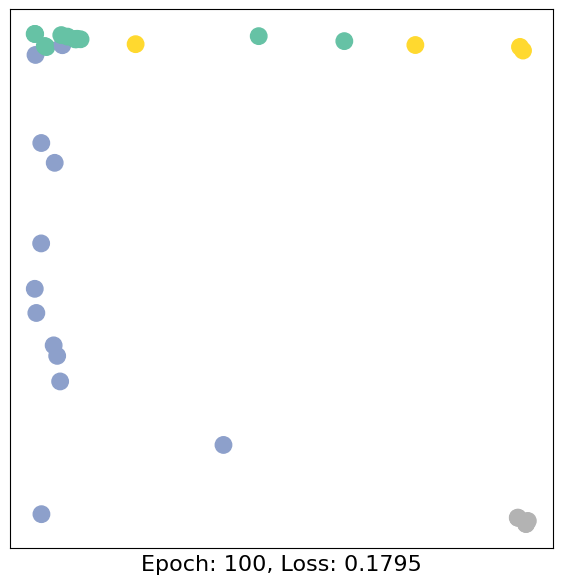

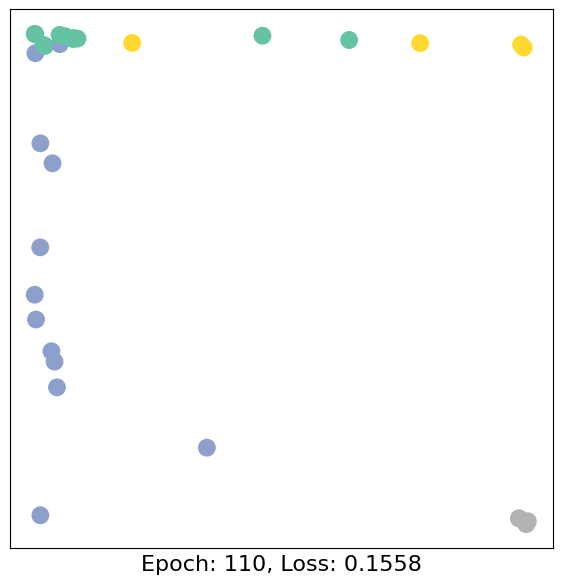

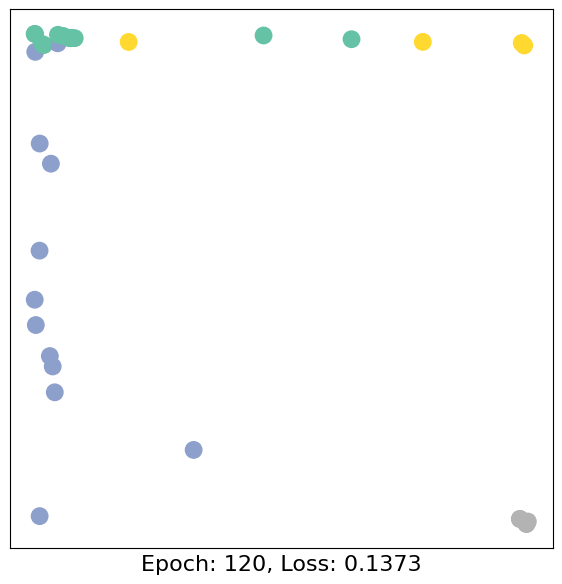

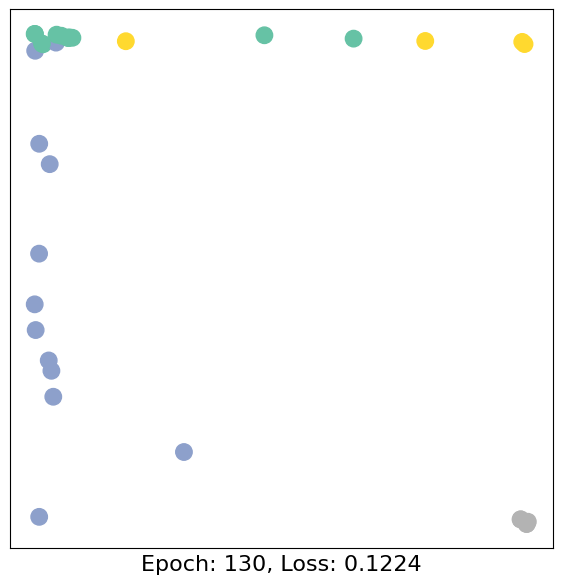

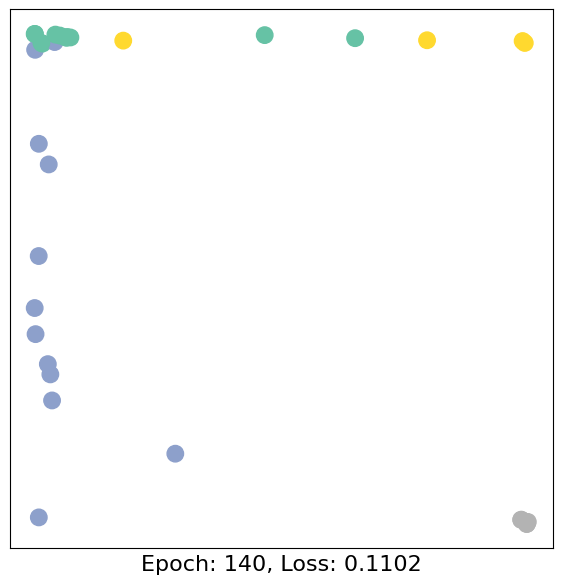

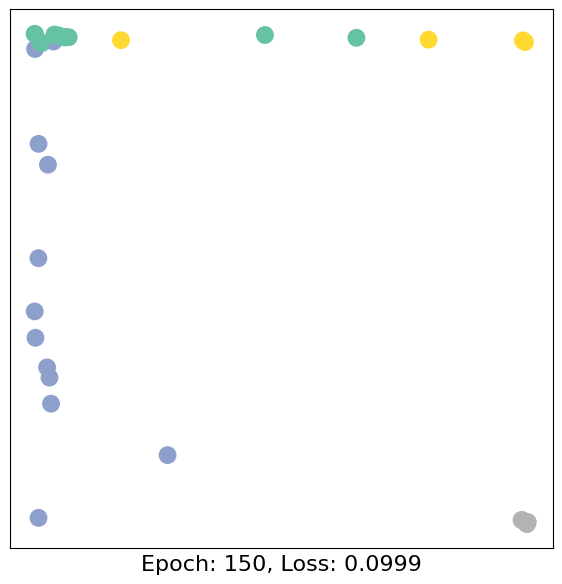

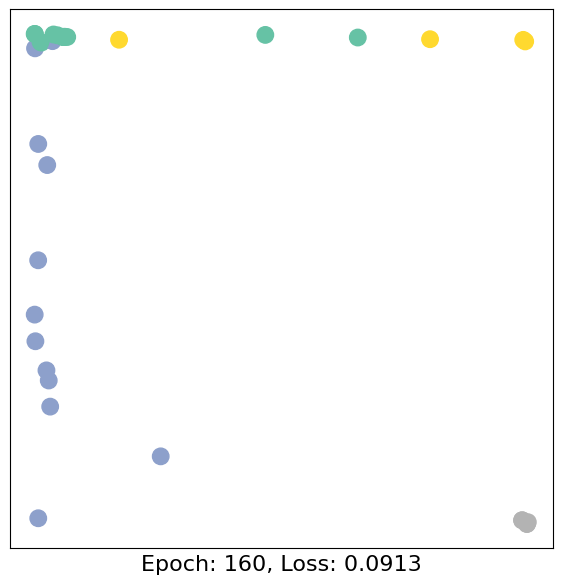

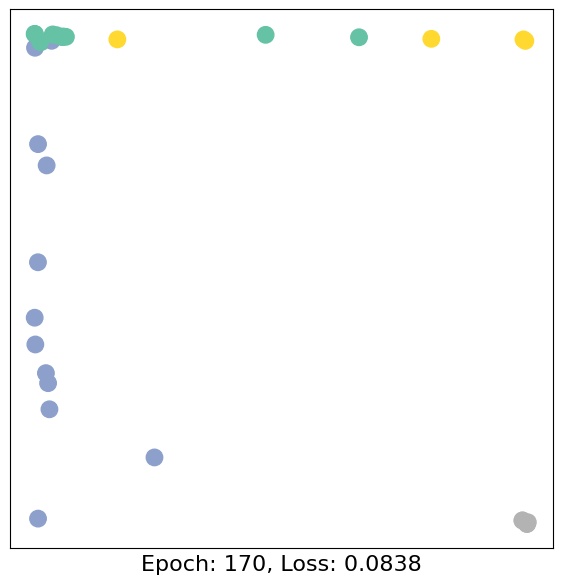

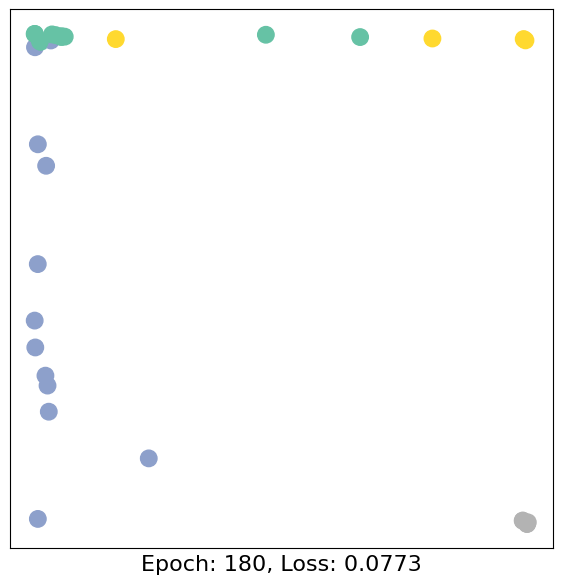

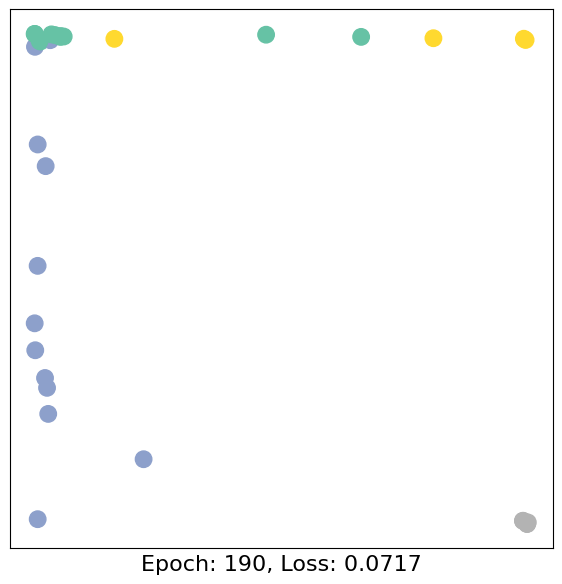

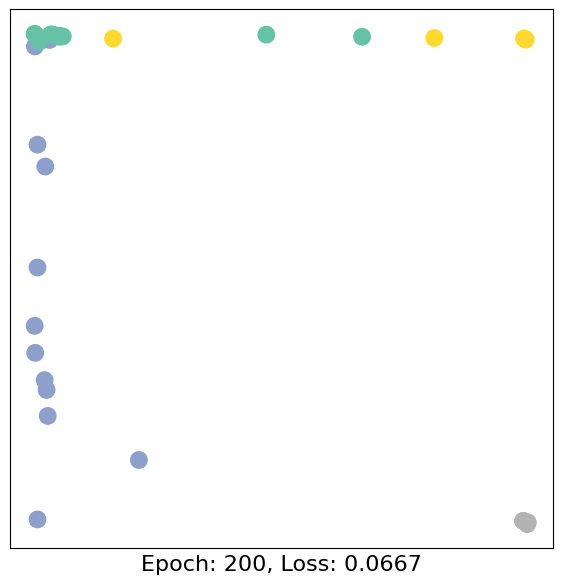

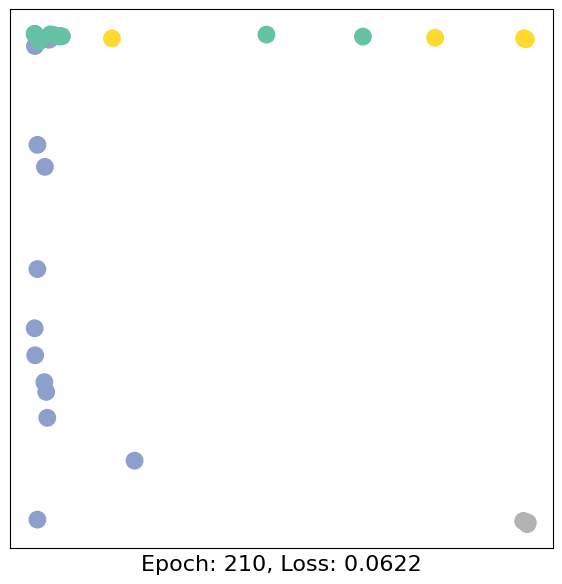

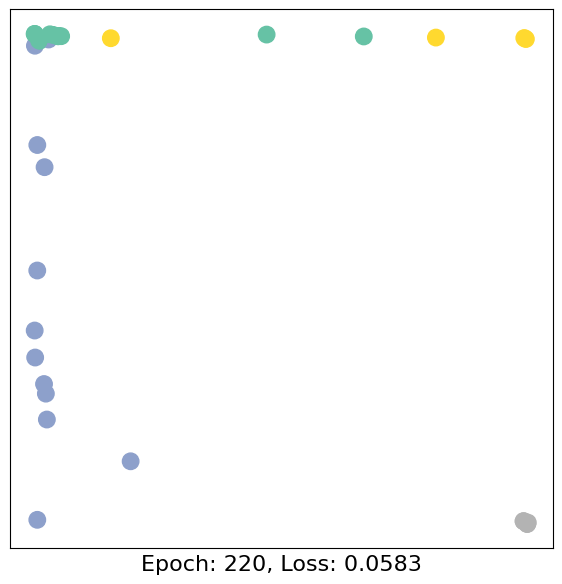

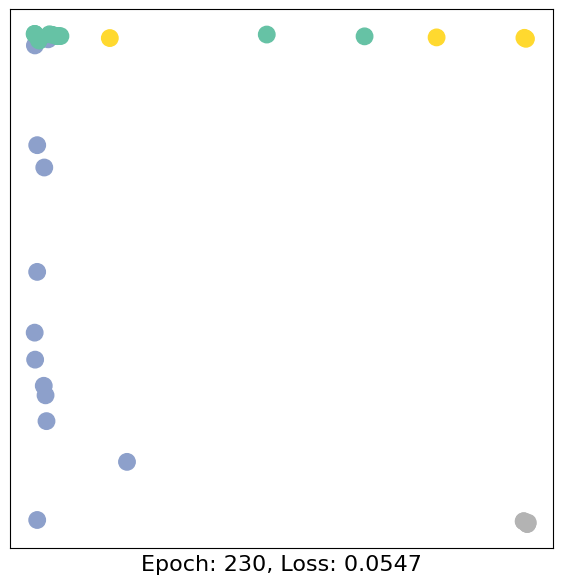

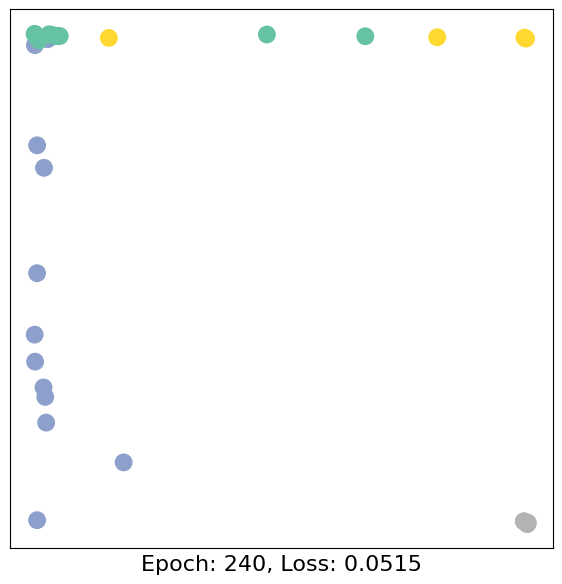

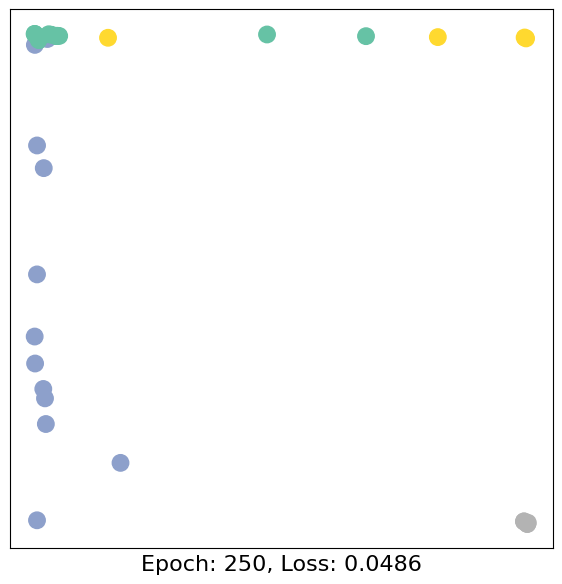

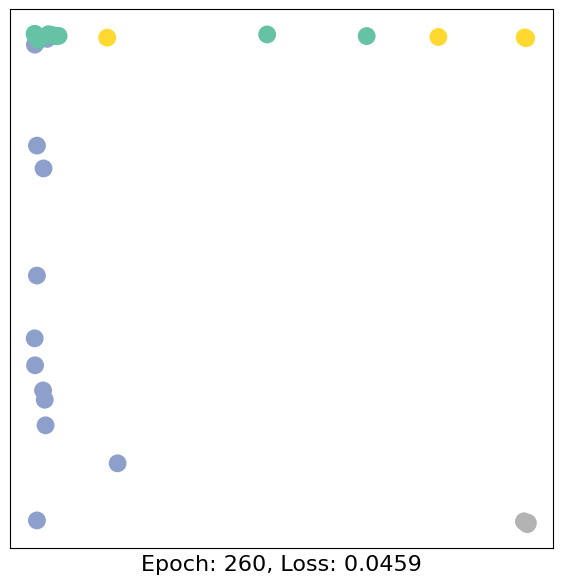

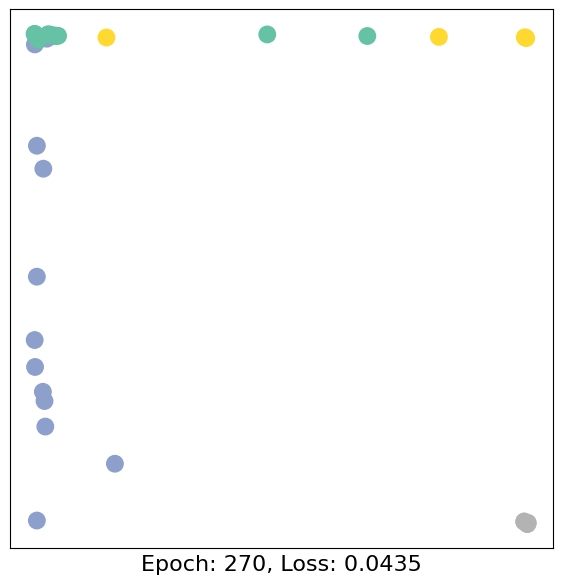

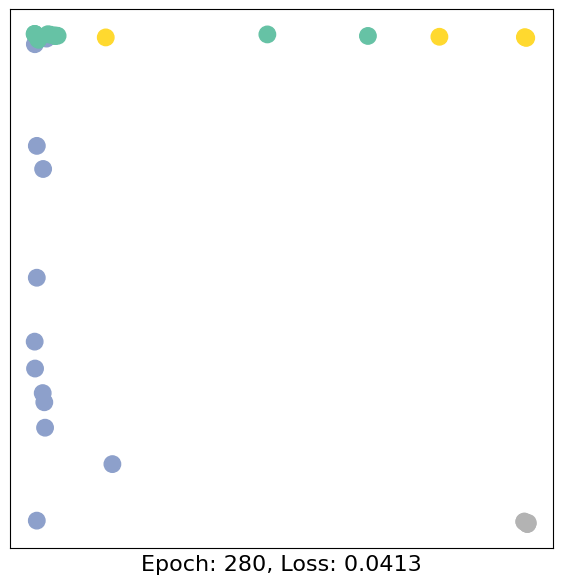

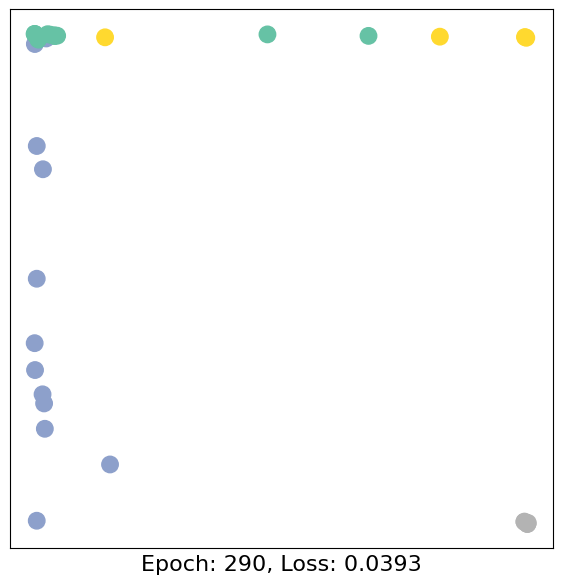

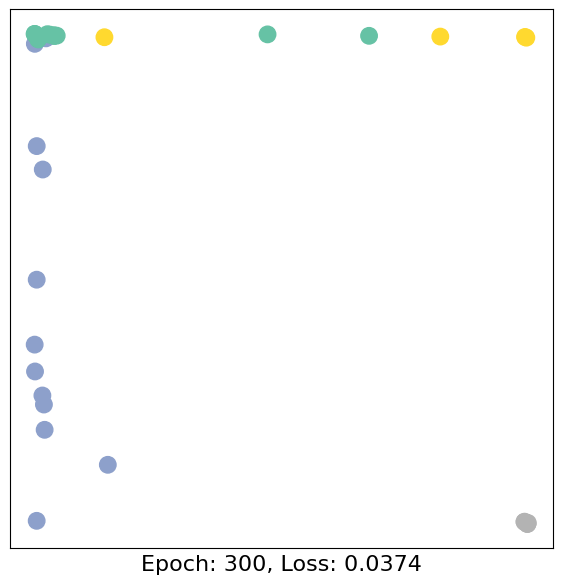

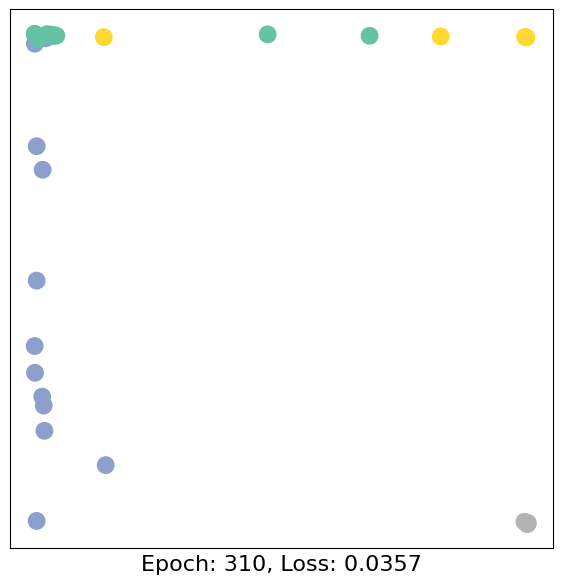

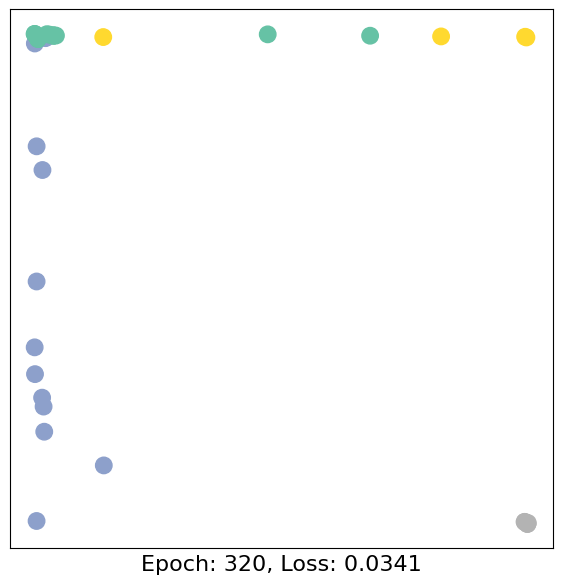

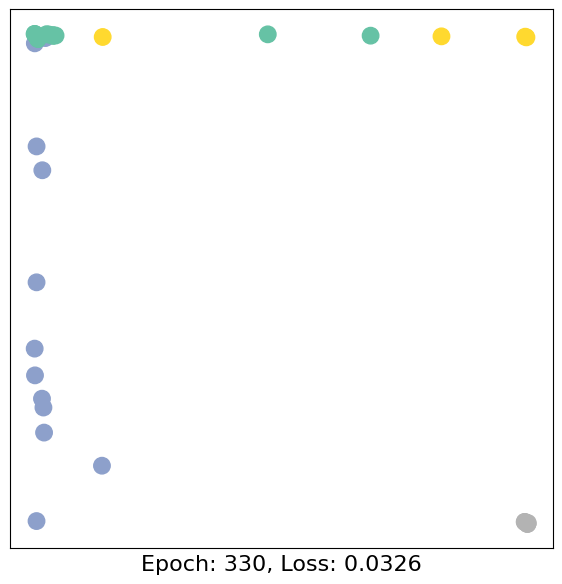

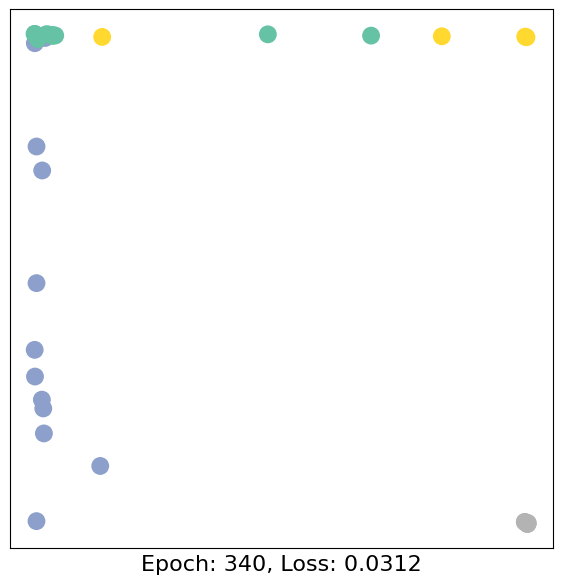

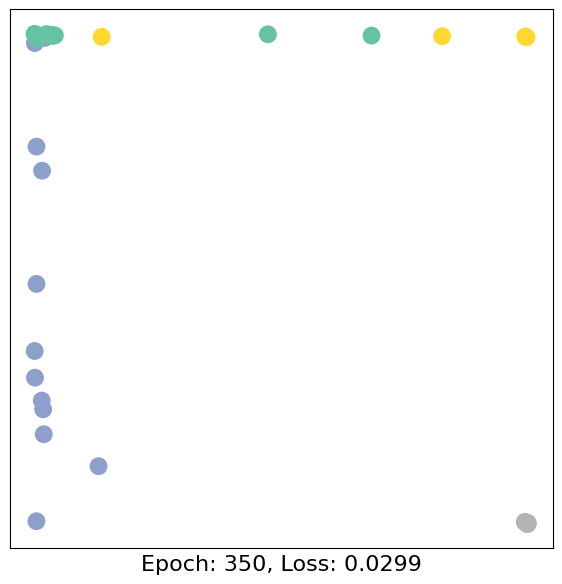

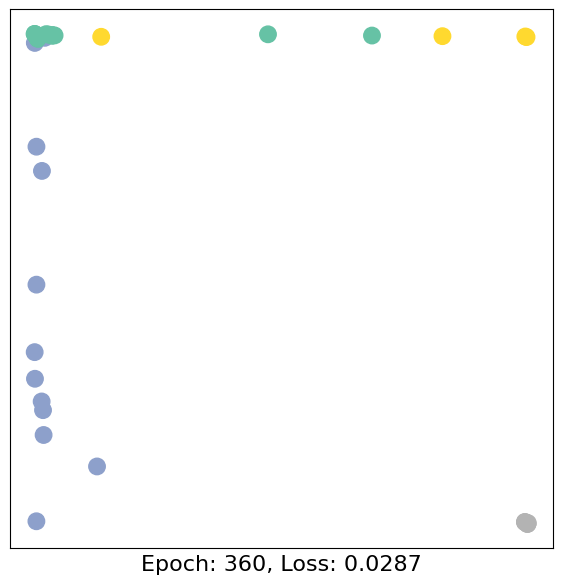

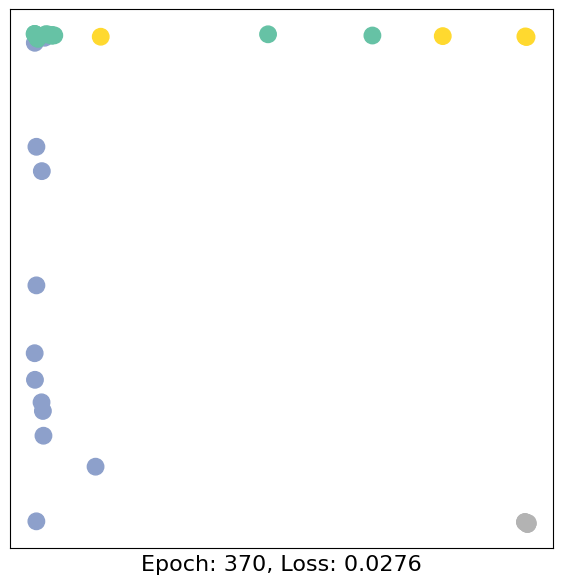

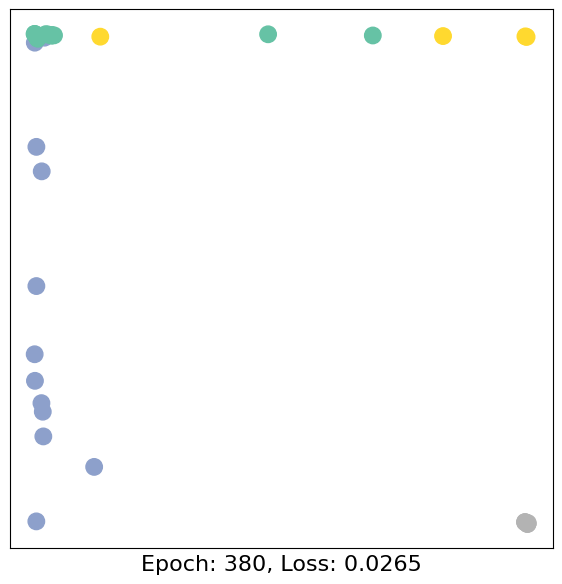

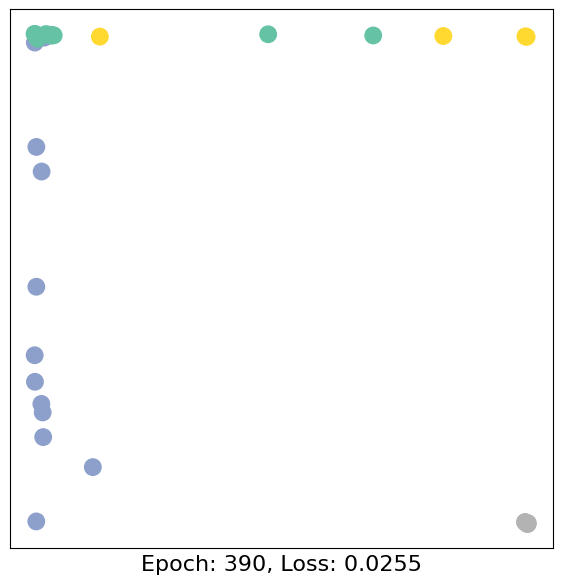

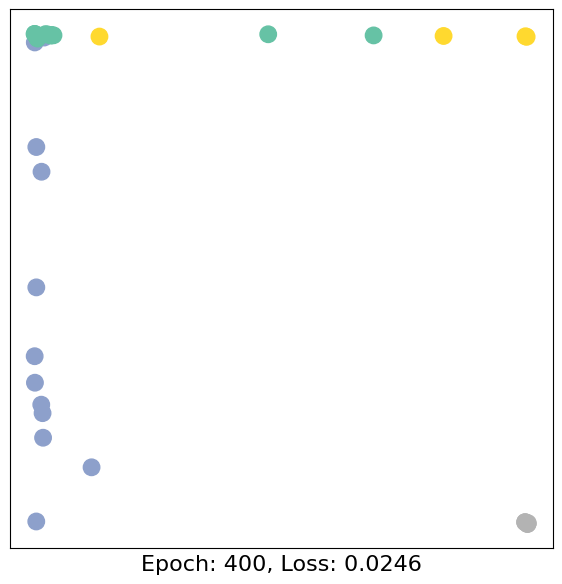

In [ ]:
import time
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 430})'''))

model = GCN()
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer. The optimizer updates the model weights using gradients computed during backpropagation.
                                                          #Learning rate: Controls how much weights change after each update. Too large → training may become unstable.
                                                          #Too small → training becomes very slow.
def train(data):           #Defines the training function.
    optimizer.zero_grad()  # Clears old gradients from the previous training step.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass. Runs a forward pass through the GCN. out = predicted class scores (logits).
                                            #h = learned node embeddings.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, h    #Returns: loss → training error. h → node embeddings learned by the GCN.

    #In one sentence: This function runs the GCN on the graph, calculates the training loss,
    #updates the model weights using gradient descent, and returns the loss and node embeddings.

for epoch in range(401):
    loss, h = train(data)# Performs one training step. loss = current training loss. h = current node embeddings.
    if epoch % 10 == 0:
        visualize_embedding(h, color=data.y, epoch=epoch, loss=loss)
        time.sleep(0.3)

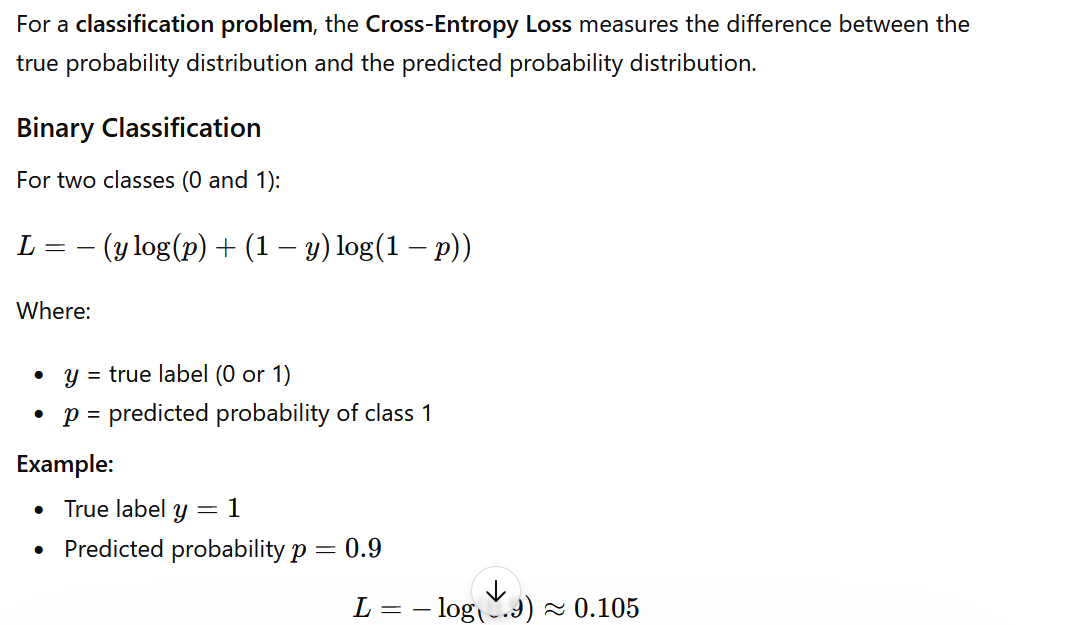

As one can see, our 3-layer GCN model manages to linearly separating the communities and classifying most of the nodes correctly.

Furthermore, we did this all with a few lines of code, thanks to the PyTorch Geometric library which helped us out with data handling and GNN implementations.

## Conclusion

This concludes the first introduction into the world of GNNs and PyTorch Geometric.
In the follow-up sessions, you will learn how to achieve state-of-the-art classification results on a number of real-world graph datasets.

